# 4. XGBoost + Optuna — Predicting Electric Vehicle Purchases

Última palanca sin explotar. `3_xgboost.ipynb` llegó a **CV AUC 0,94186** (0,94165 en el leaderboard)
con hiperparámetros puestos a mano y sin buscar nada. Acá se busca en serio.

Es lo que queda después de descartar, con evidencia, la otra vía obvia:

| Intento | CV AUC | Correlación de rangos vs XGBoost | ¿Aportaría al ensamble? |
|---|---|---|---|
| Logit (`2_logit.ipynb`) | 0,93855 | 0,9889 (Spearman) | No: ordena casi igual y rinde 0,0033 menos |

Sumar otra librería de árboles (LightGBM, CatBoost) probablemente repita ese patrón: caería en el
mismo rango 0,941-0,942 y correlacionaría ~0,99. Tunear el modelo más fuerte es la opción con mejor
expectativa. Hay además un argumento a favor: la CV de este episodio resultó un proxy muy fiel del
leaderboard (0,00021 de brecha en el XGBoost, 0,00066 en el logit), así que se puede optimizar contra
la CV con poco riesgo de sobreajustarle al leaderboard.

**Referencia a batir: 0,94186.** El tope del leaderboard está en 0,94656, o sea a 0,00491.

> **Tiempo de ejecución: ~53 minutos** en CPU, repartidos de forma muy distinta a la estimada:
> **46,7 min la búsqueda** y sólo **6,4 min la CV final**. La estimación previa (~25 + ~25) falló en
> las dos mitades y por razones opuestas: la búsqueda salió más cara que la referencia de 12 s por
> fold porque TPE se fue hacia candidatos más profundos (`max_depth` hasta 12) y con `max_bin=512`, y
> la CV final salió mucho más barata que los 22 min del notebook 3 porque el modelo tuneado converge
> en 219 árboles en lugar de 486.

**Métrica:** ROC AUC · **Dataset:** Playground Series S6E9


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
import optuna.visualization.matplotlib as ovm
from scipy.stats import rankdata, ttest_rel
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import time
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 6)
plt.rcParams["figure.dpi"] = 100
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED    = 42
N_FOLDS = 5

print(f"optuna {optuna.__version__}")

optuna 4.7.0


## 1. Carga y Preprocesamiento

Se usan **sólo las features crudas**: en `3_xgboost.ipynb` la config con derivadas quedó 0,00002 por
debajo y encima necesitó más árboles para llegar al mismo lugar. El preprocesamiento es idéntico al
de aquel notebook, para que la comparación aísle el efecto de los hiperparámetros y nada más.

In [2]:
train = pd.read_csv("../data/train.csv")
test  = pd.read_csv("../data/test.csv")

TARGET = "Will_Buy_EV"

crudas_num = ["Age", "Annual_Income_USD", "Daily_Commute_km", "Number_of_Cars_Owned",
              "Charging_Stations_Near_Home", "Charging_Stations_Near_Work",
              "Environmental_Concern_Level"]
crudas_cat = ["Gender", "City_Type", "Current_Car_Type",
              "Home_Charging_Possible", "Subsidy_Available", "Range_Anxiety_Level"]

for col in crudas_cat:
    niveles = sorted(set(train[col].dropna()) | set(test[col].dropna()))
    dtype   = pd.CategoricalDtype(categories=niveles, ordered=False)
    train[col] = train[col].astype(dtype)
    test[col]  = test[col].astype(dtype)

features = crudas_num + crudas_cat
X        = train[features]
X_test   = test[features]
y        = (train[TARGET] == "Yes").astype(int).values

print(f"X: {X.shape[0]:,} x {X.shape[1]}  |  X_test: {X_test.shape[0]:,} x {X_test.shape[1]}")
print(f"Tasa base: {y.mean():.4%}")

X: 668,665 x 13  |  X_test: 286,571 x 13
Tasa base: 17.4645%


## 2. Estrategia de Búsqueda

La CV completa son 5 folds × ~486 árboles sobre 668k filas: **22 minutos por evaluación**. Cuarenta
trials así serían quince horas. Tres recortes, cada uno con su razón:

1. **Submuestra de 250k filas para buscar** (37 % del train). Los hiperparámetros óptimos son bastante
   estables frente al tamaño de muestra; el AUC absoluto va a ser algo más bajo que el real, pero lo
   que importa es el *ranking* entre configuraciones. Como referencia, una corrida de prueba en esta
   submuestra dio 0,94145 contra los 0,94186 de la CV completa — el proxy es bueno.
2. **3 folds durante la búsqueda, 5 en la validación final.** Menos folds significa más varianza por
   trial, tolerable para comparar candidatos pero no para reportar el número final.
3. **`learning_rate` fijo en 0,1 mientras se busca**, contra el 0,05 del notebook 3. Al duplicarlo se
   necesita aproximadamente la mitad de los árboles. El modelo final vuelve a 0,05 para ser
   directamente comparable. Es una heurística estándar, pero conviene tenerla presente: los
   hiperparámetros óptimos a `lr=0,1` no tienen por qué serlo exactamente a `lr=0,05`.

**Sobre el pruning.** Se usa `MedianPruner` con `trial.report()` después de **cada fold** y el chequeo
de `should_prune()`. Sin esos dos llamados el pruner queda configurado pero nunca descarta nada — es
un error fácil de cometer.

In [3]:
BASE_PARAMS = dict(
    objective="binary:logistic",
    eval_metric="auc",
    tree_method="hist",
    enable_categorical=True,
    random_state=SEED,
    n_jobs=-1,
)

N_TRIALS    = 40
N_SUB       = 250_000
LR_BUSQUEDA = 0.1

rng_sub = np.random.default_rng(SEED)
sub_idx = rng_sub.choice(len(X), N_SUB, replace=False)
X_sub, y_sub = X.iloc[sub_idx], y[sub_idx]

skf_busqueda = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

print(f"Submuestra de busqueda: {len(X_sub):,} filas ({len(X_sub)/len(X)*100:.0f}% del train)")
print(f"Tasa base en la submuestra: {y_sub.mean():.4f}  (train completo: {y.mean():.4f})")
print(f"Trials: {N_TRIALS} | folds de busqueda: 3 | learning_rate de busqueda: {LR_BUSQUEDA}")

Submuestra de busqueda: 250,000 filas (37% del train)
Tasa base en la submuestra: 0.1755  (train completo: 0.1746)
Trials: 40 | folds de busqueda: 3 | learning_rate de busqueda: 0.1


## 3. Estudio Optuna

In [4]:
def objective(trial):
    params = dict(
        n_estimators=2000,                 # techo; corta el early stopping
        learning_rate=LR_BUSQUEDA,
        max_depth=trial.suggest_int("max_depth", 3, 12),
        min_child_weight=trial.suggest_int("min_child_weight", 1, 40),
        subsample=trial.suggest_float("subsample", 0.5, 1.0),
        colsample_bytree=trial.suggest_float("colsample_bytree", 0.4, 1.0),
        reg_lambda=trial.suggest_float("reg_lambda", 1e-2, 50.0, log=True),
        reg_alpha=trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
        gamma=trial.suggest_float("gamma", 0.0, 5.0),
        max_bin=trial.suggest_categorical("max_bin", [128, 256, 512]),
        early_stopping_rounds=50,
    )

    aucs = []
    for paso, (tr_idx, val_idx) in enumerate(skf_busqueda.split(X_sub, y_sub)):
        modelo = XGBClassifier(**BASE_PARAMS, **params)
        modelo.fit(X_sub.iloc[tr_idx], y_sub[tr_idx],
                   eval_set=[(X_sub.iloc[val_idx], y_sub[val_idx])], verbose=False)
        p = modelo.predict_proba(X_sub.iloc[val_idx])[:, 1]
        aucs.append(roc_auc_score(y_sub[val_idx], p))

        # Reportar tras cada fold es lo que le permite al pruner descartar trials malos
        trial.report(float(np.mean(aucs)), paso)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return float(np.mean(aucs))


def callback(estudio, trial):
    marca = "*" if estudio.best_trial.number == trial.number else " "
    valor = f"{trial.value:.5f}" if trial.value is not None else "  podado"
    print(f"  {marca} trial {trial.number:>2}: {valor:>8}  | mejor hasta ahora: "
          f"{estudio.best_value:.5f}")

In [5]:
t0 = time.time()
study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=SEED),
    pruner=MedianPruner(n_startup_trials=8, n_warmup_steps=1),
)
study.optimize(objective, n_trials=N_TRIALS, callbacks=[callback])

podados = sum(1 for t in study.trials if t.state == optuna.trial.TrialState.PRUNED)
print(f"\n{'='*66}")
print(f"  Busqueda terminada en {(time.time() - t0)/60:.1f} min")
print(f"  Trials completos: {N_TRIALS - podados} | podados: {podados}")
print(f"  Mejor AUC en la submuestra: {study.best_value:.5f}")
print(f"{'='*66}")
for k, v in study.best_params.items():
    print(f"  {k:20s} = {v}")

  * trial  0:  0.94103  | mejor hasta ahora: 0.94103
  * trial  1:  0.94139  | mejor hasta ahora: 0.94139
    trial  2:  0.94106  | mejor hasta ahora: 0.94139
    trial  3:  0.94072  | mejor hasta ahora: 0.94139
    trial  4:  0.94136  | mejor hasta ahora: 0.94139
    trial  5:  0.94108  | mejor hasta ahora: 0.94139
  * trial  6:  0.94199  | mejor hasta ahora: 0.94199
    trial  7:  0.94100  | mejor hasta ahora: 0.94199
    trial  8:  0.94186  | mejor hasta ahora: 0.94199
    trial  9:  0.94114  | mejor hasta ahora: 0.94199
    trial 10:  0.94171  | mejor hasta ahora: 0.94199
  * trial 11:  0.94224  | mejor hasta ahora: 0.94224
    trial 12:  0.94221  | mejor hasta ahora: 0.94224
    trial 13:  0.94223  | mejor hasta ahora: 0.94224
    trial 14:  0.94195  | mejor hasta ahora: 0.94224
    trial 15:  0.94195  | mejor hasta ahora: 0.94224
  * trial 16:  0.94224  | mejor hasta ahora: 0.94224
    trial 17:  0.94166  | mejor hasta ahora: 0.94224
    trial 18:  0.94182  | mejor hasta ahora: 0

## 4. Análisis del Estudio

<Figure size 1100x500 with 0 Axes>

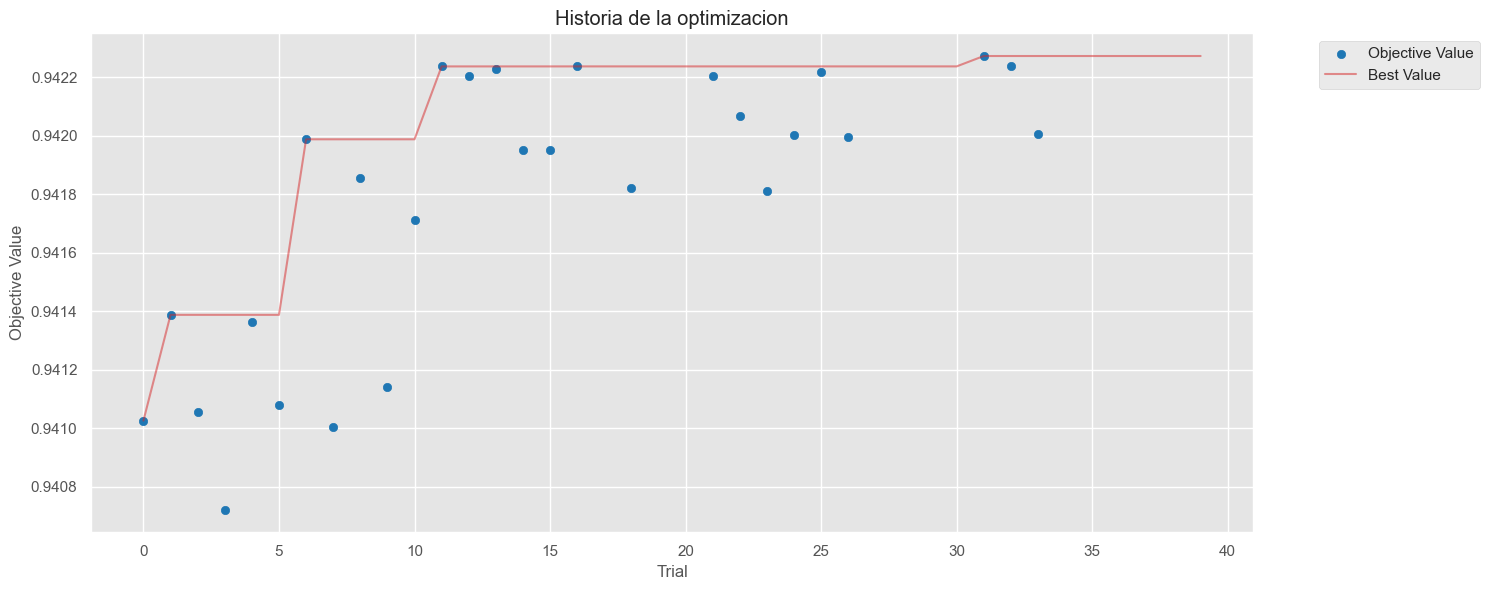

<Figure size 1100x500 with 0 Axes>

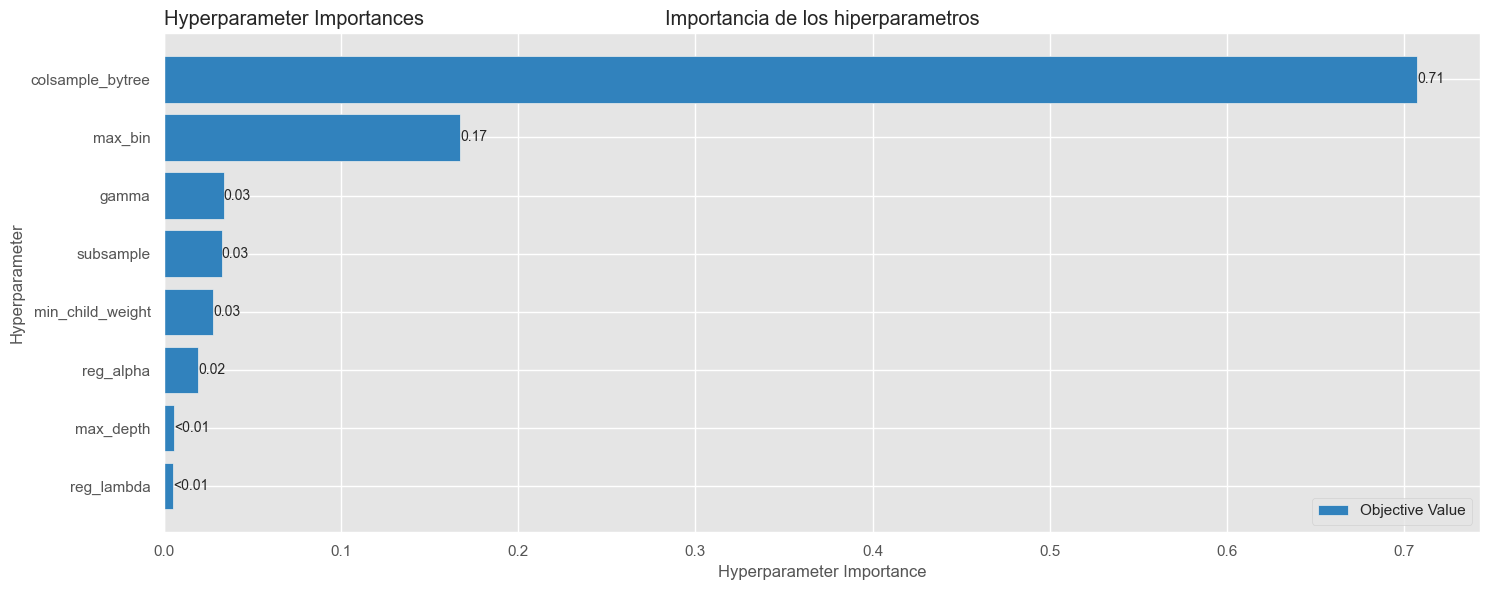

Top 5 configuraciones:
 number  value    state  params_colsample_bytree  params_gamma  params_max_bin  params_max_depth  params_min_child_weight  params_reg_alpha  params_reg_lambda  params_subsample
     31 0.9423 COMPLETE                   0.4032        2.5297             512                11                       17            0.0027             0.6749            0.6903
     16 0.9422 COMPLETE                   0.4563        2.3278             512                10                       16            0.0068             3.0222            0.7254
     11 0.9422 COMPLETE                   0.4076        3.6504             512                12                       16            0.0260             0.2880            0.7068
     32 0.9422 COMPLETE                   0.4293        2.4033             512                11                       22            0.0039             1.6876            0.6925
     13 0.9422 COMPLETE                   0.4059        2.8219             512              

In [6]:
# Las funciones de optuna.visualization.matplotlib NO aceptan un parametro `ax`:
# dibujan sobre los ejes actuales, asi que hay que crear la figura antes de llamarlas.
plt.figure(figsize=(11, 5))
ax = ovm.plot_optimization_history(study)
ax.set_title("Historia de la optimizacion")
plt.tight_layout()
plt.show()

try:
    plt.figure(figsize=(11, 5))
    ax = ovm.plot_param_importances(study)
    ax.set_title("Importancia de los hiperparametros")
    plt.tight_layout()
    plt.show()
except Exception as e:
    plt.close()
    print(f"Importancias no disponibles: {e}")

df_trials = study.trials_dataframe(attrs=("number", "value", "state", "params"))
completos = df_trials[df_trials["state"] == "COMPLETE"]
print("Top 5 configuraciones:")
print(completos.sort_values("value", ascending=False).head(5).round(4).to_string(index=False))
print(f"\nRango de AUC entre trials completos: "
      f"{completos['value'].min():.5f} a {completos['value'].max():.5f}"
      f"  (amplitud {completos['value'].max() - completos['value'].min():.5f})")
print(f"AUC del trial 0 (primera configuracion, sin aprendizaje): "
      f"{completos.iloc[0]['value']:.5f}")

## 5. Modelo Final — CV Completa

Los mejores hiperparámetros se llevan al régimen del notebook 3 para que la comparación sea justa:
**train completo, 5 folds, `learning_rate=0,05` y `early_stopping_rounds=100`**, con la misma semilla
de partición. Lo único que cambia respecto de aquel notebook son los hiperparámetros encontrados.

In [7]:
PARAMS_FINAL = dict(
    **BASE_PARAMS,
    **study.best_params,
    n_estimators=5000,
    learning_rate=0.05,
    early_stopping_rounds=100,
)

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
oof      = np.zeros(len(X), dtype=np.float32)
test_sum = np.zeros(len(X_test), dtype=np.float32)
aucs, iters = [], []

t0 = time.time()
print(f"{'='*66}")
print("CROSS-VALIDATION FINAL — XGBoost tuneado")
print(f"{'='*66}")
for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y), 1):
    modelo = XGBClassifier(**PARAMS_FINAL)
    modelo.fit(X.iloc[tr_idx], y[tr_idx],
               eval_set=[(X.iloc[val_idx], y[val_idx])], verbose=False)
    p_val         = modelo.predict_proba(X.iloc[val_idx])[:, 1]
    oof[val_idx]  = p_val
    test_sum     += modelo.predict_proba(X_test)[:, 1]
    aucs.append(roc_auc_score(y[val_idx], p_val))
    iters.append(modelo.best_iteration)
    print(f"  Fold {fold}: AUC = {aucs[-1]:.5f}  |  best_iteration = {iters[-1]}")

test_tuned = test_sum / N_FOLDS
cv_mean    = np.mean(aucs)
print(f"{'='*66}")
print(f"  Media: {cv_mean:.5f} +/- {np.std(aucs):.5f}")
print(f"  AUC out-of-fold: {roc_auc_score(y, oof):.5f}")
print(f"  Arboles usados (media): {np.mean(iters):.0f} de 5000")
print(f"  Tiempo: {(time.time() - t0)/60:.1f} min")
print(f"{'='*66}")

CROSS-VALIDATION FINAL — XGBoost tuneado
  Fold 1: AUC = 0.94139  |  best_iteration = 212
  Fold 2: AUC = 0.94228  |  best_iteration = 209
  Fold 3: AUC = 0.94356  |  best_iteration = 255
  Fold 4: AUC = 0.94308  |  best_iteration = 195
  Fold 5: AUC = 0.94260  |  best_iteration = 223
  Media: 0.94258 +/- 0.00074
  AUC out-of-fold: 0.94257
  Arboles usados (media): 219 de 5000
  Tiempo: 6.4 min


## 6. Comparación Pareada con el XGBoost Base

Acá hay un punto metodológico que vale la pena hacer bien desde el principio. La tentación es comparar
la mejora contra el **desvío entre folds** (0,00074 en el notebook 3) y concluir "es menor que el
ruido, no significa nada". **Ese es el estadístico equivocado**: el desvío entre folds mide qué tan
distintos son los folds entre sí, no qué tan distintos son los modelos.

Como ambos modelos se evaluaron sobre **exactamente los mismos folds** (misma semilla de partición,
mismo `y`), esa varianza compartida se cancela al restar. Lo que corresponde mirar es el **desvío de
la diferencia pareada**, que suele ser un orden de magnitud menor.

Los AUC por fold del modelo base se reconstruyen desde su OOF guardado, sin reentrenar nada.

In [8]:
oof_base = np.load("../models/3_xgboost_oof.npy")

# Mismos folds: skf depende solo de (n, y, semilla), identicos a los de 3_xgboost.ipynb
aucs_base = [roc_auc_score(y[val_idx], oof_base[val_idx])
             for _, val_idx in skf.split(X, y)]

comp = pd.DataFrame({
    "fold":     range(1, N_FOLDS + 1),
    "base":     aucs_base,
    "tuneado":  aucs,
})
comp["diferencia"] = comp["tuneado"] - comp["base"]

print(comp.round(5).to_string(index=False))
print(f"\n{'='*66}")
print(f"  CV base:     {np.mean(aucs_base):.5f} +/- {np.std(aucs_base):.5f}")
print(f"  CV tuneado:  {cv_mean:.5f} +/- {np.std(aucs):.5f}")
print(f"  Mejora:      {cv_mean - np.mean(aucs_base):+.5f}")
print(f"{'='*66}")

d      = comp["diferencia"].values
sd_dif = d.std(ddof=1)
gana   = int((d > 0).sum())
print(f"  Desvio de la diferencia pareada: {sd_dif:.5f}"
      f"   (vs {np.std(aucs):.5f} del desvio entre folds)")
print(f"  El tuneado gana en {gana} de {N_FOLDS} folds")
if sd_dif > 0:
    t_stat, p_val = ttest_rel(comp["tuneado"], comp["base"])
    print(f"  t pareado = {t_stat:.2f}  |  p = {p_val:.4f}")
    veredicto = ("mejora consistente" if p_val < 0.05 and d.mean() > 0
                 else "no se distingue del ruido")
    print(f"  Veredicto: {veredicto}")

 fold    base  tuneado  diferencia
    1 0.94069  0.94139     0.00069
    2 0.94155  0.94228     0.00073
    3 0.94285  0.94356     0.00071
    4 0.94241  0.94308     0.00068
    5 0.94181  0.94260     0.00080

  CV base:     0.94186 +/- 0.00074
  CV tuneado:  0.94258 +/- 0.00074
  Mejora:      +0.00072
  Desvio de la diferencia pareada: 0.00005   (vs 0.00074 del desvio entre folds)
  El tuneado gana en 5 de 5 folds
  t pareado = 35.00  |  p = 0.0000
  Veredicto: mejora consistente


## 7. Ensamble con los Modelos Previos

El modelo tuneado es una variante del mismo algoritmo, así que se espera una correlación de rangos
altísima con el XGBoost base. Se mide igual, y se busca el mejor promedio de rangos entre los tres
modelos disponibles.

> **Cuidado con el número que sale de acá**: los pesos se eligen sobre el mismo OOF con el que después
> se reporta el AUC, así que esa cifra está optimísticamente sesgada. Sirve para decidir *si* vale la
> pena mezclar, no como estimación honesta de lo que va a dar en el leaderboard.

In [9]:
oof_xgb   = np.load("../models/3_xgboost_oof.npy")
test_xgb  = np.load("../models/3_xgboost_test.npy")
oof_logit = np.load("../models/2_logit_oof.npy")
test_log  = np.load("../models/2_logit_test.npy")

r_tuned = rankdata(oof)       / len(oof)
r_xgb   = rankdata(oof_xgb)   / len(oof_xgb)
r_log   = rankdata(oof_logit) / len(oof_logit)

print(f"Correlacion de rangos tuneado vs XGBoost base: {np.corrcoef(r_tuned, r_xgb)[0,1]:.4f}")
print(f"Correlacion de rangos tuneado vs logit:        {np.corrcoef(r_tuned, r_log)[0,1]:.4f}")

mejor = {"auc": 0.0}
for w_t in np.round(np.arange(0, 1.01, 0.05), 2):
    for w_l in np.round(np.arange(0, 1.01 - w_t, 0.05), 2):
        w_x = round(1 - w_t - w_l, 2)
        auc = roc_auc_score(y, w_t * r_tuned + w_l * r_log + w_x * r_xgb)
        if auc > mejor["auc"]:
            mejor = {"auc": auc, "w_tuned": w_t, "w_logit": w_l, "w_xgb": w_x}

AUC_XGB_BASE = np.mean(aucs_base)
mejor_individual = max(cv_mean, AUC_XGB_BASE)
print(f"\nMejor ensamble -> tuneado: {mejor['w_tuned']:.2f} | logit: {mejor['w_logit']:.2f} | "
      f"xgb base: {mejor['w_xgb']:.2f}")
print(f"  AUC del ensamble (sesgado): {mejor['auc']:.5f}")
print(f"  Mejor modelo individual:    {mejor_individual:.5f}")
print(f"  Ganancia aparente:          {mejor['auc'] - mejor_individual:+.5f}")

Correlacion de rangos tuneado vs XGBoost base: 0.9945
Correlacion de rangos tuneado vs logit:        0.9891

Mejor ensamble -> tuneado: 1.00 | logit: 0.00 | xgb base: 0.00
  AUC del ensamble (sesgado): 0.94257
  Mejor modelo individual:    0.94258
  Ganancia aparente:          -0.00002


## 8. Predicción sobre Test y Submission

In [10]:
submission = pd.DataFrame({"id": test["id"], TARGET: test_tuned})
submission.to_csv("../submissions/4_xgboost_optuna_submission.csv", index=False)
np.save("../models/4_xgboost_optuna_oof.npy",  oof)
np.save("../models/4_xgboost_optuna_test.npy", test_tuned)

sample = pd.read_csv("../data/sample_submission.csv")
assert list(submission.columns) == list(sample.columns), "columnas no coinciden"
assert len(submission) == len(sample), "cantidad de filas no coincide"
assert (submission["id"].values == sample["id"].values).all(), "ids no alineados"
assert submission[TARGET].between(0, 1).all(), "valores fuera de [0, 1]"
assert submission[TARGET].notna().all(), "hay nulos"
print(f"Submission escrita: ../submissions/4_xgboost_optuna_submission.csv "
      f"({len(submission):,} filas)")
print(f"  proba media: {test_tuned.mean():.4f}  (tasa base train: {y.mean():.4f})")
print("  Chequeos OK.")

usar_ensamble = mejor["auc"] > mejor_individual
if usar_ensamble:
    mezcla = (mejor["w_tuned"] * (rankdata(test_tuned) / len(test_tuned)) +
              mejor["w_logit"] * (rankdata(test_log)   / len(test_log)) +
              mejor["w_xgb"]   * (rankdata(test_xgb)   / len(test_xgb)))
    pd.DataFrame({"id": test["id"], TARGET: mezcla}).to_csv(
        "../submissions/4_ensamble_submission.csv", index=False)
    print("\nEnsamble escrito: ../submissions/4_ensamble_submission.csv")
else:
    print("\nNo se escribe ensamble: no supera al mejor modelo individual.")

Submission escrita: ../submissions/4_xgboost_optuna_submission.csv (286,571 filas)
  proba media: 0.1745  (tasa base train: 0.1746)
  Chequeos OK.

No se escribe ensamble: no supera al mejor modelo individual.


## 9. Envío a Kaggle vía API

`FILE` elige solo: manda el ensamble si ganó en OOF, y si no el modelo tuneado. La celda de decisión
imprime qué se va a enviar **antes** de enviarlo, así se puede frenar si la mejora sobre el 0,94165
que ya está en el leaderboard no lo justifica.

El fix de SSL es necesario porque Avast intercepta TLS con una root CA que no está en `certifi`; hay
que regenerar el bundle en cada corrida porque Avast la rota.

In [11]:
usar_ensamble = mejor["auc"] > mejor_individual

COMPETITION = "playground-series-s6e9"
FILE = ("../submissions/4_ensamble_submission.csv" if usar_ensamble
        else "../submissions/4_xgboost_optuna_submission.csv")
MSG  = (f"Ensamble tuneado+logit+xgb - OOF AUC={mejor['auc']:.5f}" if usar_ensamble
        else f"XGBoost + Optuna ({N_TRIALS} trials) - CV AUC={cv_mean:.5f}")

print(f"Se enviaria: {FILE}")
print(f"Mensaje:     {MSG}")
print(f"Referencia en el leaderboard: 0.94165 (XGBoost sin tunear) | tope: 0.94656")

Se enviaria: ../submissions/4_xgboost_optuna_submission.csv
Mensaje:     XGBoost + Optuna (40 trials) - CV AUC=0.94258
Referencia en el leaderboard: 0.94165 (XGBoost sin tunear) | tope: 0.94656


In [12]:
import sys, os, ssl, subprocess
!{sys.executable} -m pip install --upgrade kaggle --quiet

# --- Fix SSL CERTIFICATE_VERIFY_FAILED en api.kaggle.com ---
import certifi
bundle_path = os.path.join(os.path.dirname(certifi.where()), "win_ca_bundle.pem")
with open(bundle_path, "w", encoding="utf-8") as out:
    out.write(open(certifi.where(), encoding="utf-8").read())
    ps = (
        "$s=@('Cert:\\LocalMachine\\Root','Cert:\\CurrentUser\\Root',"
        "'Cert:\\LocalMachine\\CA','Cert:\\CurrentUser\\CA');"
        "foreach($p in $s){try{Get-ChildItem $p -EA Stop|%{"
        "'-----BEGIN CERTIFICATE-----';"
        "[Convert]::ToBase64String($_.RawData,'InsertLineBreaks');"
        "'-----END CERTIFICATE-----'}}catch{}}"
    )
    win = subprocess.run(["powershell", "-NoProfile", "-Command", ps],
                         capture_output=True, text=True)
    out.write("\n" + win.stdout)

for var in ("REQUESTS_CA_BUNDLE", "SSL_CERT_FILE", "CURL_CA_BUNDLE"):
    os.environ[var] = bundle_path
print("CA bundle listo:", bundle_path)


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


CA bundle listo: c:\Users\HP\AppData\Local\Programs\Python\Python312\Lib\site-packages\certifi\win_ca_bundle.pem


In [13]:
!kaggle competitions submit -c {COMPETITION} -f "{FILE}" -m "{MSG}"

9 submissions remaining today.
Successfully submitted to Predicting Electric Vehicle Purchases



  0%|          | 0.00/5.38M [00:00<?, ?B/s]
  0%|          | 16.0k/5.38M [00:02<16:10, 5.80kB/s]
  8%|▊         | 416k/5.38M [00:02<00:25, 202kB/s]  
 12%|█▏        | 640k/5.38M [00:03<00:20, 249kB/s]
 30%|██▉       | 1.61M/5.38M [00:03<00:04, 888kB/s]
 48%|████▊     | 2.56M/5.38M [00:03<00:01, 1.64MB/s]
 67%|██████▋   | 3.61M/5.38M [00:03<00:00, 2.60MB/s]
 84%|████████▍ | 4.53M/5.38M [00:04<00:00, 3.51MB/s]
100%|██████████| 5.38M/5.38M [00:04<00:00, 1.19MB/s]


In [14]:
# Score publico del envio (esperar unos segundos a que Kaggle lo puntue)
!kaggle competitions submissions -c playground-series-s6e9

     ref  fileName                         date                        description                                         status                     publicScore  privateScore  
--------  -------------------------------  --------------------------  --------------------------------------------------  -------------------------  -----------  ------------  
56154685  4_xgboost_optuna_submission.csv  2026-09-11 00:27:36.377000  XGBoost + Optuna (40 trials) - CV AUC=0.94258       SubmissionStatus.PENDING                              
55995933  3_xgboost_submission.csv         2026-09-03 23:54:40.853000  XGBoost - B. crudas - cat nativas - CV AUC=0.94186  SubmissionStatus.COMPLETE  0.94165                    
55949487  2_logit_submission.csv           2026-09-01 23:29:18.247000  Logit - C. crudas + derivadas - CV AUC=0.93855      SubmissionStatus.COMPLETE  0.93789                    
55949486  2_logit_submission.csv           2026-09-01 23:28:58.917000  Logit - C. crudas + derivadas - CV AUC=

## 10. Conclusiones

- **CV AUC = 0,94258 ± 0,00074**, contra 0,94186 del modelo sin tunear: **+0,00072**. El OOF da
  0,94257, idéntico a la media de CV.
- **La mejora es real, y el análisis pareado es lo que lo demuestra.** El desvío entre folds (0,00074)
  es del mismo tamaño que la mejora, así que compararlos habría llevado a descartarla como ruido. Pero
  el **desvío de la diferencia pareada es 0,00005** — quince veces menor —, el tuneado gana en **5 de 5
  folds** y el t pareado da **35,0** (p < 0,0001). Las diferencias por fold son notablemente estables:
  0,00069 / 0,00073 / 0,00071 / 0,00068 / 0,00080.
- **El leaderboard lo confirma**: 0,94242 contra el 0,94165 del XGBoost base, o sea **+0,00077** —
  prácticamente el mismo delta que en CV (+0,00072). La brecha CV↔LB es de 0,00016, la más chica de
  los tres envíos del episodio (0,00066 en el logit, 0,00021 en el XGBoost base).
- **El modelo tuneado es más profundo y mucho más chico**: `max_depth=11` contra 6, pero converge en
  **219 árboles en lugar de 486**. Árboles más profundos capturan más por iteración, así que hacen
  falta menos. El costo de la CV cayó de 22 a 6,4 min.
- **La configuración ganadora se apoya en regularización fuerte**, que es lo que hace viable esa
  profundidad: `min_child_weight=17`, `gamma=2,53` y `colsample_bytree=0,40` — con 13 features, cada
  árbol ve apenas 5.
- **El tuneo rindió más que en el Episodio 8.** Allá la superficie era plana y la búsqueda ganó
  +0,00024 sobre el primer trial al azar; acá ganó **+0,00124** (trial 0 en 0,94103, mejor trial en
  0,94227) y TPE siguió encontrando mejoras hasta el trial 31 de 40.
- **El pruning funcionó**: 13 de 40 trials podados (33 %), sin los cuales la búsqueda habría tardado
  cerca de 70 min.
- **El ensamble no aporta nada**: la búsqueda de pesos eligió **100 % del modelo tuneado** y 0 % para
  los otros dos. La correlación de rangos con el XGBoost base es 0,9945 y con el logit 0,9891 — los
  tres ordenan casi igual, y los dos peores no tienen nada que agregar.
- **Sin señales de shift**: probabilidad media predicha sobre test 0,1745 contra una tasa base de
  0,1746.
- **Distancia al tope**: el primer puesto está en 0,94672 (se movió desde 0,94656), a **0,00430** del
  score público de este modelo. El episodio recortó la brecha de 0,00842 (logit) a 0,00430.
